#### 14-Nedan ser vi en början till modellering av ett dataset kopplat till diabetes. Läs på vad datasetet innebär och genomför ett komplett ML-flöde. Börja med att göra ett grundläggande flöde som fungerar, därefter kan du om du önskar försöka förbättra resultatet.


In [2]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [3]:

data = load_diabetes()
print(data.DESCR.split(".. data #")[0])
# Datasetet innehåller 442 diabetespatienter. X är tio standardiserade
# medicinska mätvärden och y är ett kvantitativt mått på sjukdomens utveckling.

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [4]:
X, y = load_diabetes(return_X_y=True, as_frame=True)
print(f"Antal rader: {X.shape[0]}, antal variabler: {X.shape[1]}")
print(X.head())
print(y.describe())

Antal rader: 442, antal variabler: 10
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  
count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64


In [5]:

# Dela upp data så att testdata inte används vid träning.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:

# Grundmodell: linjär regression passar eftersom målet är numeriskt.
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

MAE: 42.79
RMSE: 53.85
R²: 0.45


     Verkligt värde  Predikterat värde
287           219.0         139.547558
211            70.0         179.517208
72            202.0         134.038756
321           230.0         291.417029
73            111.0         123.789659
418            84.0          92.172347
367           242.0         258.232389
354           272.0         181.337321
281            94.0          90.224113
148            96.0         108.633759


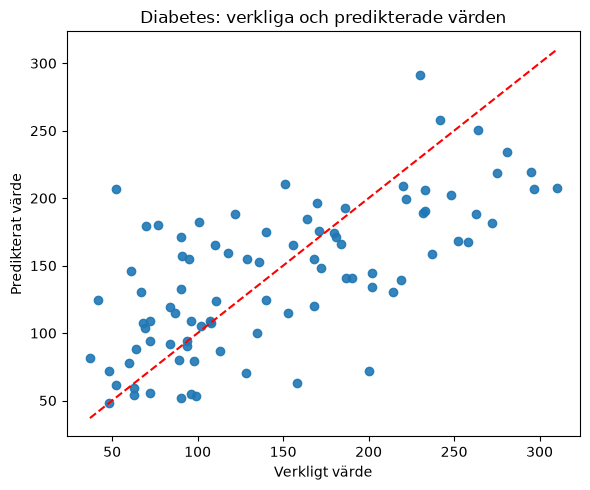

In [15]:

# Enkel kontroll av modellens prediktioner.
results = y_test.to_frame(name="Verkligt värde")
results["Predikterat värde"] = y_pred
print(results.head(10))

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.9)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Verkligt värde")
plt.ylabel("Predikterat värde")
plt.title("Diabetes: verkliga och predikterade värden")
plt.tight_layout()
plt.show()